## Operon Segmentation — Isoform-based

Segment the *Syn1* minimal cell genome (~1.08 Mb, 911 genes) into operons directly from PacBio FLNC long-read RNA-seq.

**Biological rationale:** In bacteria, genes are co-transcribed in polycistronic operons from a shared promoter. A single full-length RNA isoform spanning multiple genes is therefore the natural evidence for operon membership. PacBio FLNC reads capture complete transcripts from TSS to TTS, making them ideal for operon discovery without relying on depth drop-offs or intergenic gap heuristics.

**Key insight:** Under containment-only clustering, each operon is defined by its **longest isoform** — the full-length transcript spanning the true TSS to TTS. All shorter co-clustered isoforms are nested subsets arising from RNase degradation or premature termination and do not change the boundary.

**Complications addressed:**
- *RNase activity* — bacteria actively degrade mRNA from the 3′ end and internally; this fragments a single operon transcript into multiple shorter isoforms that can appear as separate clusters.
- *Low-abundance transcripts* — essential genes under low expression may produce too few reads to pass the isoform threshold; these are rescued using BAM-level read evidence.
- *rRNA operons* — rRNA transcripts are too abundant and structured for isoform clustering; these two operons (each encoding 5S–23S–16S) are annotated directly from the genome.

**Single tunable parameter:** `MIN_READS` — minimum read support per isoform cluster.

**Input:** `isoform_clusters_annotated.tsv` — 80 K clustered isoforms with genomic coordinates, strand, and read support.

**Output:** `operons.candidate_blocks.tsv` — full operon table with gene annotations and segmentation type.

## Step 1 — Load isoforms

Filter the ~80 K clustered isoforms to those with at least `MIN_READS` supporting reads. Lower thresholds retain more isoforms but risk including sequencing noise and spurious clusters; higher thresholds miss lowly-expressed operons. At `MIN_READS = 50` the dominant transcription units are well-supported while RNase-generated fragments (which typically accumulate fewer reads than full-length transcripts) are partially suppressed.

In [21]:
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd

# ── Paths ──────────────────────────────────────────────────────────────────
MOTHER_FOLDER = ".."
ISOFORMS_TSV  = MOTHER_FOLDER + "/isoform_annotation/isoform_clusters_annotated.tsv"
OUT_FOLDER    = MOTHER_FOLDER + "/Operon_Annotation_Visualization"
Path(OUT_FOLDER).mkdir(parents=True, exist_ok=True)

# ── Single parameter ───────────────────────────────────────────────────────
MIN_READS = 50   # minimum read support per isoform — only tunable parameter

# ── Load ───────────────────────────────────────────────────────────────────
df = pd.read_csv(ISOFORMS_TSV, sep="\t")
df_iso = df[df["n_reads"] >= MIN_READS].copy()

print(f"Total isoforms loaded: {len(df)}")
print(f"Isoforms with n_reads >= {MIN_READS}: {len(df_iso)}")
print(f"\nStrand breakdown:")
print(df_iso["strand"].value_counts().to_string())

Total isoforms loaded: 82794
Isoforms with n_reads >= 50: 4064

Strand breakdown:
strand
+    2098
-    1966


## Step 2 — Containment clustering → initial operons

**Biological basis:** Each operon produces one primary full-length transcript (longest isoform) and many degradation/truncation products. All products of the same operon are nested subsets of the full-length transcript. Two isoforms from *different* operons may overlap at their boundaries but one will not be fully contained within the other.

**Clustering rule:** Isoforms i and j join the same cluster iff one is fully contained within the other (within `BOUNDARY_TOL` bp tolerance to absorb soft-clipping). Partially overlapping isoforms — characteristic of adjacent operons whose 3′ and 5′ ends interleave — are **never** merged here.

**Mathematical guarantee:** The cluster boundary always equals the longest isoform. If any member extended beyond the longest isoform's boundaries, that member would itself be longer — a contradiction.

**Parameters:**
- `MIN_READS` — isoform read-support threshold (Step 1)
- `BOUNDARY_TOL` — boundary tolerance in bp; absorbs minor coordinate variation from soft-clipping at read ends

**Implementation:** Union-Find with path compression on containment pairs; sweep-line reduces candidate comparisons from O(n²) to O(n log n).

In [22]:
BOUNDARY_TOL = 10   # bp — isoforms within this many bp of containment are treated as contained

def cluster_isoforms(isoforms: pd.DataFrame,
                     tol: int = BOUNDARY_TOL) -> list[dict]:
    """
    Cluster isoforms into operons by containment (with tolerance).

    Two isoforms i and j are in the same cluster iff one is within `tol` bp
    of being fully contained within the other:
        start_i >= start_j - tol  AND  end_i <= end_j + tol   (i inside j)
        OR vice-versa.

    The cluster boundary = the outermost (longest) isoform.
    Uses union-find + sweep-line for efficiency.
    """
    if isoforms.empty:
        return []

    iso    = isoforms.reset_index(drop=True)
    starts = iso["start0"].astype(int).tolist()
    ends   = iso["end0"].astype(int).tolist()
    n      = len(iso)

    # ── Union-Find with path compression ───────────────────────────────────
    parent = list(range(n))
    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x
    def union(x, y):
        parent[find(x)] = find(y)

    # ── Sweep: for each isoform i, check candidates j that start near i ────
    order = sorted(range(n), key=lambda i: starts[i])
    for idx, i in enumerate(order):
        si, ei = starts[i], ends[i]
        for j in order[idx + 1:]:
            sj = starts[j]
            if sj >= ei + tol:   # j starts well after i ends — no containment possible
                break
            ej = ends[j]
            # near-containment: i inside j (with tol), or j inside i (with tol)
            i_in_j = (si >= sj - tol) and (ei <= ej + tol)
            j_in_i = (sj >= si - tol) and (ej <= ei + tol)
            if i_in_j or j_in_i:
                union(i, j)

    # ── Collect connected components → one block each ──────────────────────
    components = defaultdict(list)
    for i in range(n):
        components[find(i)].append(i)

    chrom  = iso.loc[0, "chrom"]
    strand = iso.loc[0, "strand"]
    blocks = []
    for indices in components.values():
        members = [iso.loc[k, "isoform_id"] for k in indices]
        reads   = [int(iso.loc[k, "n_reads"])  for k in indices]
        s0 = min(starts[k] for k in indices)
        e0 = max(ends[k]   for k in indices)
        blocks.append({
            "chrom": chrom, "strand": strand,
            "start0": s0, "end0": e0,
            "members": members, "reads": reads,
        })
    return sorted(blocks, key=lambda b: b["start0"])


def blocks_to_df(blocks: list[dict]) -> pd.DataFrame:
    rows = [{
        "chrom":         b["chrom"],
        "strand":        b["strand"],
        "start0":        b["start0"],
        "end0":          b["end0"],
        "n_isoforms":    len(b["members"]),
        "n_reads_total": int(np.sum(b["reads"])),
        "member_ids":    ",".join(b["members"]),
    } for b in blocks]
    return pd.DataFrame(rows) if rows else pd.DataFrame(
        columns=["chrom","strand","start0","end0","n_isoforms","n_reads_total","member_ids"])


# ── Cluster per strand ──────────────────────────────────────────────────────
operons_plus  = cluster_isoforms(df_iso[df_iso["strand"] == "+"])
operons_minus = cluster_isoforms(df_iso[df_iso["strand"] == "-"])

GENOME_LEN = 1_079_433   # CP002027.1 Syn1 genome length (bp)
def genome_coverage_pct(blocks, genome_len=GENOME_LEN):
    covered = sum(b["end0"] - b["start0"] for b in blocks)
    return covered, covered / genome_len * 100

cov_plus_bp,  cov_plus_pct  = genome_coverage_pct(operons_plus)
cov_minus_bp, cov_minus_pct = genome_coverage_pct(operons_minus)
print(f"BOUNDARY_TOL = {BOUNDARY_TOL} bp")
print(f"Operons — plus: {len(operons_plus)}, minus: {len(operons_minus)}, total: {len(operons_plus)+len(operons_minus)}")
print(f"Genome coverage — plus:  {cov_plus_bp:>8,} bp  ({cov_plus_pct:.1f}%)")
print(f"                  minus: {cov_minus_bp:>8,} bp  ({cov_minus_pct:.1f}%)")

# ── Build final DataFrame ───────────────────────────────────────────────────
all_blocks  = sorted(operons_plus + operons_minus, key=lambda b: (b["chrom"], b["start0"]))
operons_all = blocks_to_df(all_blocks)
operons_all.insert(0, "operon_id", [f"OP_{i+1:05d}" for i in range(len(operons_all))])
operons_all["length"] = operons_all["end0"] - operons_all["start0"]

# TSS/TTS: directional 5\'→3\' coordinates
# + strand: TSS = start0 (low), TTS = end0 (high)
# − strand: TSS = end0  (high), TTS = start0 (low)
operons_all["tss"] = np.where(operons_all["strand"] == "+",
                               operons_all["start0"], operons_all["end0"])
operons_all["tts"] = np.where(operons_all["strand"] == "+",
                               operons_all["end0"],  operons_all["start0"])

print(f"\nLength distribution (bp):")
print(operons_all["length"].describe().astype(int).to_string())

display(operons_all.drop(columns="member_ids").head(20))


BOUNDARY_TOL = 10 bp
Operons — plus: 148, minus: 168, total: 316
Genome coverage — plus:   342,030 bp  (31.7%)
                  minus:  406,815 bp  (37.7%)

Length distribution (bp):
count     316
mean     2369
std      1290
min       411
25%      1496
50%      2100
75%      2955
max      8240


,operon_id,chrom,strand,start0,end0,n_isoforms,n_reads_total,length,tss,tts
0,OP_00001,CP002027.1,+,0,2659,9,12489,2659,0,2659
1,OP_00002,CP002027.1,+,4270,5404,2,227,1134,4270,5404
2,OP_00003,CP002027.1,+,5255,8212,4,588,2957,5255,8212
3,OP_00004,CP002027.1,+,6573,9976,5,415,3403,6573,9976
4,OP_00005,CP002027.1,-,11647,16812,7,876,5165,16812,11647
5,OP_00006,CP002027.1,-,16955,18528,3,2706,1573,18528,16955
6,OP_00007,CP002027.1,+,18689,20919,1,86,2230,18689,20919
7,OP_00008,CP002027.1,+,21648,24088,3,1320,2440,21648,24088
8,OP_00009,CP002027.1,-,25237,27549,3,356,2312,27549,25237
9,OP_00010,CP002027.1,+,27121,28928,11,31694,1807,27121,28928


## Step 3 — Gene annotation

Map the 911 annotated Syn1 genes (from GFF3) onto the isoform-derived operons. Each operon is annotated with:
- **Sense genes** — annotated genes on the *same strand* that overlap the operon coordinates; these are the genes the operon is transcribing.
- **Antisense genes** — annotated genes on the *opposite strand* that overlap the same genomic window; these reflect the dense gene packing of the minimal genome, where antisense transcription or convergent/divergent gene pairs are common.

Running gene annotation here — before the overlap and coverage analyses — makes gene context immediately available for diagnosing same-strand operon boundary conflicts in Step 4.

In [23]:
import re

GFF3_FILE = MOTHER_FOLDER + "/Genomes_Input/syn1.genes.gff3"

# ── Parse GFF3 (1-based closed → 0-based half-open) ────────────────────────
gene_records = []
with open(GFF3_FILE) as fh:
    for line in fh:
        if line.startswith("#") or not line.strip():
            continue
        parts = line.rstrip("\n").split("\t")
        if len(parts) < 9 or parts[2] != "gene":
            continue
        chrom  = parts[0]
        start1 = int(parts[3])
        end1   = int(parts[4])
        strand = parts[6]
        attrs  = parts[8]
        locus  = re.search(r"locus_tag=([^;]+)", attrs)
        name   = re.search(r"Name=([^;]+)",      attrs)
        prod   = re.search(r"product=([^;]+)",   attrs)
        gene_records.append({
            "chrom":     chrom,
            "strand":    strand,
            "start0":    start1 - 1,
            "end0":      end1,
            "locus_tag": locus.group(1) if locus else "",
            "gene_name": name.group(1)  if name  else "",
            "product":   prod.group(1)  if prod  else "",
        })

genes_df = pd.DataFrame(gene_records)
print(f"Genes loaded: {len(genes_df)}")
print(genes_df["strand"].value_counts().to_string())


# ── Annotate each operon with sense AND antisense overlapping genes ─────────
def annotate_operons_with_genes(operons: pd.DataFrame,
                                genes: pd.DataFrame) -> pd.DataFrame:
    """
    For each operon add:
      sense_gene_count / sense_gene_loci / sense_gene_names
          — genes on the SAME strand that overlap the operon
      antisense_gene_count / antisense_gene_loci / antisense_gene_names
          — genes on the OPPOSITE strand that overlap the operon
    """
    ops = operons.copy()
    opp = {"+": "-", "-": "+"}
    s_counts, s_loci, s_names = [], [], []
    a_counts, a_loci, a_names = [], [], []

    for _, op in ops.iterrows():
        overlaps  = (genes["start0"] < op["end0"]) & (genes["end0"] > op["start0"])
        sense     = genes[overlaps & (genes["strand"] == op["strand"])]
        antisense = genes[overlaps & (genes["strand"] == opp[op["strand"]])]
        s_counts.append(len(sense));  s_loci.append(",".join(sense["locus_tag"]));  s_names.append(",".join(sense["gene_name"]))
        a_counts.append(len(antisense)); a_loci.append(",".join(antisense["locus_tag"])); a_names.append(",".join(antisense["gene_name"]))

    ops["sense_gene_count"]     = s_counts
    ops["sense_gene_loci"]      = s_loci
    ops["sense_gene_names"]     = s_names
    ops["antisense_gene_count"] = a_counts
    ops["antisense_gene_loci"]  = a_loci
    ops["antisense_gene_names"] = a_names
    ops["gene_count"] = ops["sense_gene_count"] + ops["antisense_gene_count"]
    ops["gene_loci"]  = ops["sense_gene_loci"]
    ops["gene_names"] = ops["sense_gene_names"]
    return ops

operons_annotated = annotate_operons_with_genes(operons_all, genes_df)

print(f"\nOperons with sense genes:")
print(f"  0 sense genes:   {(operons_annotated['sense_gene_count'] == 0).sum()}")
print(f"  1 sense gene:    {(operons_annotated['sense_gene_count'] == 1).sum()}")
print(f"  2 sense genes:   {(operons_annotated['sense_gene_count'] == 2).sum()}")
print(f"  3+ sense genes:  {(operons_annotated['sense_gene_count'] >= 3).sum()}")
print(f"\nOperons with >=1 antisense gene: {(operons_annotated['antisense_gene_count'] > 0).sum()}")


Genes loaded: 911
strand
-    494
+    417

Operons with sense genes:
  0 sense genes:   9
  1 sense gene:    108
  2 sense genes:   90
  3+ sense genes:  109

Operons with >=1 antisense gene: 64


In [24]:
operons_annotated.head(20)

,operon_id,chrom,strand,start0,end0,n_isoforms,n_reads_total,member_ids,length,tss,tts,sense_gene_count,sense_gene_loci,sense_gene_names,antisense_gene_count,antisense_gene_loci,antisense_gene_names,gene_count,gene_loci,gene_names
0,OP_00001,CP002027.1,+,0,2659,9,12489,"ISO_000007,ISO_000011,ISO_000013,ISO_000014,IS...",2659,0,2659,2,"MMSYN1_0001,MMSYN1_0002","dnaA_1,dnaN",0,,,2,"MMSYN1_0001,MMSYN1_0002","dnaA_1,dnaN"
1,OP_00002,CP002027.1,+,4270,5404,2,227,"ISO_000186,ISO_000189",1134,4270,5404,1,MMSYN1_0005,,0,,,1,MMSYN1_0005,
2,OP_00003,CP002027.1,+,5255,8212,4,588,"ISO_000193,ISO_000203,ISO_000216,ISO_000265",2957,5255,8212,2,"MMSYN1_0006,MMSYN1_0007","gyrB,gyrA",0,,,2,"MMSYN1_0006,MMSYN1_0007","gyrB,gyrA"
3,OP_00004,CP002027.1,+,6573,9976,5,415,"ISO_000460,ISO_000568,ISO_000574,ISO_000711,IS...",3403,6573,9976,2,"MMSYN1_0006,MMSYN1_0007","gyrB,gyrA",0,,,2,"MMSYN1_0006,MMSYN1_0007","gyrB,gyrA"
4,OP_00005,CP002027.1,-,11647,16812,7,876,"ISO_035697,ISO_035714,ISO_035719,ISO_035724,IS...",5165,16812,11647,3,"MMSYN1_0009,MMSYN1_0010,MMSYN1_0011",",,",0,,,3,"MMSYN1_0009,MMSYN1_0010,MMSYN1_0011",",,"
5,OP_00006,CP002027.1,-,16955,18528,3,2706,"ISO_036017,ISO_036019,ISO_036023",1573,18528,16955,1,MMSYN1_0012,metG,0,,,1,MMSYN1_0012,metG
6,OP_00007,CP002027.1,+,18689,20919,1,86,ISO_000793,2230,18689,20919,2,"MMSYN1_0013,MMSYN1_0014",",",0,,,2,"MMSYN1_0013,MMSYN1_0014",","
7,OP_00008,CP002027.1,+,21648,24088,3,1320,"ISO_000923,ISO_000924,ISO_000936",2440,21648,24088,3,"MMSYN1_0014,MMSYN1_0015,MMSYN1_0016",",,",0,,,3,"MMSYN1_0014,MMSYN1_0015,MMSYN1_0016",",,"
8,OP_00009,CP002027.1,-,25237,27549,3,356,"ISO_036092,ISO_036145,ISO_036142",2312,27549,25237,2,"MMSYN1_0914,MMSYN1_0917","bla,",0,,,2,"MMSYN1_0914,MMSYN1_0917","bla,"
9,OP_00010,CP002027.1,+,27121,28928,11,31694,"ISO_001155,ISO_001156,ISO_001167,ISO_001168,IS...",1807,27121,28928,0,,,2,"MMSYN1_0917,MMSYN1_0918",",his3",2,,


In [25]:
operons_annotated.sort_values("gene_count", ascending=False).head(20)

,operon_id,chrom,strand,start0,end0,n_isoforms,n_reads_total,member_ids,length,tss,tts,sense_gene_count,sense_gene_loci,sense_gene_names,antisense_gene_count,antisense_gene_loci,antisense_gene_names,gene_count,gene_loci,gene_names
250,OP_00251,CP002027.1,+,856680,861730,58,47635,"ISO_030337,ISO_030339,ISO_030341,ISO_030342,IS...",5050,856680,861730,13,"MMSYN1_0717,MMSYN1_0718,MMSYN1_0719,MMSYN1_072...",",,,,,,,,,nagB,tpiA,,gpmI",0,,,13,"MMSYN1_0717,MMSYN1_0718,MMSYN1_0719,MMSYN1_072...",",,,,,,,,,nagB,tpiA,,gpmI"
230,OP_00231,CP002027.1,-,795222,801449,179,41278,"ISO_065064,ISO_065130,ISO_065006,ISO_065008,IS...",6227,801449,795222,13,"MMSYN1_0652,MMSYN1_0653,MMSYN1_0654,MMSYN1_065...","secY,rplO,rpsE,rplR,rplF,rpsH,rpsN,rplE,rplX,r...",0,,,13,"MMSYN1_0652,MMSYN1_0653,MMSYN1_0654,MMSYN1_065...","secY,rplO,rpsE,rplR,rplF,rpsH,rpsN,rplE,rplX,r..."
231,OP_00232,CP002027.1,-,801037,806176,103,89066,"ISO_068056,ISO_066617,ISO_066738,ISO_066751,IS...",5139,806176,801037,10,"MMSYN1_0663,MMSYN1_0664,MMSYN1_0665,MMSYN1_066...","rpmC,rplP,rpsC,rplV,rpsS,rplB,rplW,rplD,rplC,rpsJ",0,,,10,"MMSYN1_0663,MMSYN1_0664,MMSYN1_0665,MMSYN1_066...","rpmC,rplP,rpsC,rplV,rpsS,rplB,rplW,rplD,rplC,rpsJ"
229,OP_00230,CP002027.1,-,791115,795146,71,24983,"ISO_064229,ISO_064235,ISO_064253,ISO_064277,IS...",4031,795146,791115,8,"MMSYN1_0644,MMSYN1_0645,MMSYN1_0646,MMSYN1_064...","rplQ,rpoA,rpsK,rpsM,rpmJ,infA,map,adk",0,,,8,"MMSYN1_0644,MMSYN1_0645,MMSYN1_0646,MMSYN1_064...","rplQ,rpoA,rpsK,rpsM,rpmJ,infA,map,adk"
122,OP_00123,CP002027.1,-,377523,383512,57,24413,"ISO_047086,ISO_047072,ISO_047045,ISO_046979,IS...",5989,383512,377523,7,"MMSYN1_0297,MMSYN1_0298,MMSYN1_0299,MMSYN1_030...","infB,,,nusA,,,polC",0,,,7,"MMSYN1_0297,MMSYN1_0298,MMSYN1_0299,MMSYN1_030...","infB,,,nusA,,,polC"
291,OP_00292,CP002027.1,+,979185,985793,17,2741,"ISO_033745,ISO_033746,ISO_033757,ISO_033791,IS...",6608,979185,985793,7,"MMSYN1_0833,MMSYN1_0834,MMSYN1_0835,MMSYN1_083...","rplI,dnaB,,,cysS,,secE",0,,,7,"MMSYN1_0833,MMSYN1_0834,MMSYN1_0835,MMSYN1_083...","rplI,dnaB,,,cysS,,secE"
99,OP_00100,CP002027.1,+,291894,298399,233,57527,"ISO_013237,ISO_013262,ISO_013270,ISO_013343,IS...",6505,291894,298399,6,"MMSYN1_0225,MMSYN1_0226,MMSYN1_0227,MMSYN1_022...","pdhA,pdhB,pdhC,lpdA,pta,ackA",0,,,6,"MMSYN1_0225,MMSYN1_0226,MMSYN1_0227,MMSYN1_022...","pdhA,pdhB,pdhC,lpdA,pta,ackA"
140,OP_00141,CP002027.1,+,445953,451377,19,17622,"ISO_020092,ISO_020098,ISO_020103,ISO_020104,IS...",5424,445953,451377,6,"MMSYN1_0356,MMSYN1_0357,MMSYN1_0358,MMSYN1_035...","rnpB,,recA,,ffh,",0,,,6,"MMSYN1_0356,MMSYN1_0357,MMSYN1_0358,MMSYN1_035...","rnpB,,recA,,ffh,"
131,OP_00132,CP002027.1,+,416446,420054,6,1127,"ISO_018595,ISO_018723,ISO_018728,ISO_018743,IS...",3608,416446,420054,6,"MMSYN1_0326,MMSYN1_0327,MMSYN1_0328,MMSYN1_032...",",scpA,scpB,,,",0,,,6,"MMSYN1_0326,MMSYN1_0327,MMSYN1_0328,MMSYN1_032...",",scpA,scpB,,,"
276,OP_00277,CP002027.1,-,933709,936510,12,5051,"ISO_075860,ISO_076070,ISO_075744,ISO_075863,IS...",2801,936510,933709,6,"MMSYN1_0792,MMSYN1_0793,MMSYN1_0794,MMSYN1_079...","atpA,atpH,atpF,atpE,atpB,",0,,,6,"MMSYN1_0792,MMSYN1_0793,MMSYN1_0794,MMSYN1_079...","atpA,atpH,atpF,atpE,atpB,"


## Step 4 — Operon overlap analysis

**Same-strand overlaps** should be zero by construction from Step 2 (containment clustering guarantees non-overlapping clusters on each strand). Any same-strand overlap therefore indicates a pair of isoforms that partially overlap without containment — typically caused by RNase cleavage producing a 5′ fragment whose 3′ end falls inside the next operon's 5′ region. These pairs are resolved by the merge rule in Step 5a:

- *Merge* if the downstream operon's TSS lies **inside a gene body** → the apparent TSS is an RNase cleavage site, not a genuine promoter.
- *Separate* if the TSS is **intergenic or within 10 nt upstream of a gene start** → a genuine promoter with a short bacterial 5′ UTR.

**Cross-strand (antisense) overlaps** are biologically expected in the compact Syn1 genome, where convergent and divergent gene pairs and naturally antisense transcription are common. These are reported for information but not resolved here.

In [26]:
def find_overlapping_pairs(df_a: pd.DataFrame, df_b: pd.DataFrame,
                           same_strand: bool) -> pd.DataFrame:
    """
    Sweep-line overlap detection between two operon DataFrames.
    Returns one row per overlapping pair with overlap_bp and overlap fractions.
    If same_strand=True, df_a and df_b should be the same strand subset.
    """
    a = df_a.sort_values("start0").reset_index(drop=True)
    b = df_b.sort_values("start0").reset_index(drop=True)

    rows = []
    bi = 0
    for _, ra in a.iterrows():
        # advance b pointer past intervals that end before ra starts
        while bi < len(b) and b.loc[bi, "end0"] <= ra["start0"]:
            bi += 1
        j = bi
        while j < len(b) and b.loc[j, "start0"] < ra["end0"]:
            rb = b.loc[j]
            # skip self-comparison
            if same_strand and ra["operon_id"] == rb["operon_id"]:
                j += 1
                continue
            ovl = min(ra["end0"], rb["end0"]) - max(ra["start0"], rb["start0"])
            if ovl > 0:
                len_a = ra["end0"] - ra["start0"]
                len_b = rb["end0"] - rb["start0"]
                rows.append({
                    "operon_a":    ra["operon_id"],
                    "strand_a":    ra["strand"],
                    "start_a":     ra["start0"],
                    "end_a":       ra["end0"],
                    "operon_b":    rb["operon_id"],
                    "strand_b":    rb["strand"],
                    "start_b":     rb["start0"],
                    "end_b":       rb["end0"],
                    "overlap_bp":  ovl,
                    "frac_of_a":   round(ovl / len_a, 3),
                    "frac_of_b":   round(ovl / len_b, 3),
                    "relationship": (
                        "a_contains_b" if ra["start0"] <= rb["start0"] and ra["end0"] >= rb["end0"]
                        else "b_contains_a" if rb["start0"] <= ra["start0"] and rb["end0"] >= ra["end0"]
                        else "partial"
                    ),
                })
            j += 1

    return pd.DataFrame(rows) if rows else pd.DataFrame(columns=[
        "operon_a","strand_a","start_a","end_a",
        "operon_b","strand_b","start_b","end_b",
        "overlap_bp","frac_of_a","frac_of_b","relationship"])


In [27]:
# ── 1. Same-strand overlap (should be zero by construction) ─────────────────
# operons_annotated carries sense_gene_loci so we can show gene context for
# each conflicting pair — useful for deciding which to merge in the RNase step.
plus_ops  = operons_annotated[operons_annotated["strand"] == "+"].copy()
minus_ops = operons_annotated[operons_annotated["strand"] == "-"].copy()

ss_plus  = find_overlapping_pairs(plus_ops,  plus_ops,  same_strand=True)
ss_minus = find_overlapping_pairs(minus_ops, minus_ops, same_strand=True)
ss_plus  = ss_plus[ss_plus["operon_a"]  < ss_plus["operon_b"]]
ss_minus = ss_minus[ss_minus["operon_a"] < ss_minus["operon_b"]]
same_strand_overlaps = pd.concat([ss_plus, ss_minus], ignore_index=True)

# Annotate each pair with sense gene loci from operons_annotated
op_gene_map = operons_annotated.set_index("operon_id")["sense_gene_loci"].to_dict()
if len(same_strand_overlaps):
    same_strand_overlaps["genes_a"] = same_strand_overlaps["operon_a"].map(op_gene_map)
    same_strand_overlaps["genes_b"] = same_strand_overlaps["operon_b"].map(op_gene_map)

print(f"Same-strand overlapping operon pairs: {len(same_strand_overlaps)}")
if len(same_strand_overlaps) > 0:
    print("  -> Caused by isoforms that partially overlap without containment.")
    print("  -> These pairs are candidates for merging in the RNase-rescue step.")
    # display(same_strand_overlaps[["operon_a","operon_b","strand_a",
    #                                "start_a","end_a","start_b","end_b",
    #                                "overlap_bp","frac_of_a","frac_of_b",
    #                                "relationship","genes_a","genes_b"]])


Same-strand overlapping operon pairs: 30
  -> Caused by isoforms that partially overlap without containment.
  -> These pairs are candidates for merging in the RNase-rescue step.


In [28]:
# ── Pairs where genes_a and genes_b share at least one gene locus ────────────
# A shared gene means both operons claim the same gene on the same strand —
# a direct conflict that should be resolved by merging the two operons.

if len(same_strand_overlaps):
    def shared_loci(row):
        a = set(str(row["genes_a"]).split(",")) - {"", "nan"}
        b = set(str(row["genes_b"]).split(",")) - {"", "nan"}
        shared = a & b
        return ",".join(sorted(shared)) if shared else ""

    same_strand_overlaps["shared_genes"] = same_strand_overlaps.apply(shared_loci, axis=1)
    conflicts = same_strand_overlaps[same_strand_overlaps["shared_genes"] != ""].copy()

    print(f"Pairs with shared (conflicting) genes: {len(conflicts)} / {len(same_strand_overlaps)} total same-strand overlaps")

    if len(conflicts):
        display(conflicts[["operon_a","operon_b","strand_a",
                            "start_a","end_a","start_b","end_b",
                            "overlap_bp","frac_of_a","frac_of_b",
                            "relationship","genes_a","genes_b","shared_genes"]]
                .reset_index(drop=True))

        # Save to TSV for inspection
        OUT_SS = OUT_FOLDER + "/same_strand_gene_conflicts.tsv"
        conflicts.to_csv(OUT_SS, sep="\t", index=False)
        print(f"\nSaved: {OUT_SS}")
    else:
        print("No shared genes across conflicting pairs — overlaps are between adjacent distinct operons.")
        display(same_strand_overlaps[["operon_a","operon_b","strand_a",
                                       "start_a","end_a","start_b","end_b",
                                       "overlap_bp","relationship",
                                       "genes_a","genes_b"]].reset_index(drop=True))
else:
    print("No same-strand overlaps to analyse.")


Pairs with shared (conflicting) genes: 26 / 30 total same-strand overlaps


,operon_a,operon_b,strand_a,start_a,end_a,start_b,end_b,overlap_bp,frac_of_a,frac_of_b,relationship,genes_a,genes_b,shared_genes
0,OP_00003,OP_00004,+,5255,8212,6573,9976,1639,0.554,0.482,partial,"MMSYN1_0006,MMSYN1_0007","MMSYN1_0006,MMSYN1_0007","MMSYN1_0006,MMSYN1_0007"
1,OP_00027,OP_00028,+,84226,86713,86587,90807,126,0.051,0.030,partial,"MMSYN1_0059,MMSYN1_0060,MMSYN1_0061","MMSYN1_0061,MMSYN1_0062,MMSYN1_0063,MMSYN1_0064",MMSYN1_0061
2,OP_00057,OP_00058,+,162011,164499,164031,170016,468,0.188,0.078,partial,"MMSYN1_0125,MMSYN1_0126","MMSYN1_0126,MMSYN1_0127,MMSYN1_0128,MMSYN1_012...",MMSYN1_0126
3,OP_00081,OP_00082,+,236741,240257,239927,244480,330,0.094,0.072,partial,"MMSYN1_0180,MMSYN1_0181,MMSYN1_0182","MMSYN1_0182,MMSYN1_0183,MMSYN1_0184",MMSYN1_0182
4,OP_00106,OP_00107,+,317964,320045,319329,320427,716,0.344,0.652,partial,MMSYN1_0245,MMSYN1_0245,MMSYN1_0245
5,OP_00136,OP_00137,+,436435,437999,437395,440082,604,0.386,0.225,partial,"MMSYN1_0345,MMSYN1_0346","MMSYN1_0346,MMSYN1_0347,MMSYN1_0348",MMSYN1_0346
6,OP_00142,OP_00143,+,451462,453830,453480,455097,350,0.148,0.216,partial,"MMSYN1_0362,MMSYN1_0363,MMSYN1_0364,MMSYN1_036...","MMSYN1_0366,MMSYN1_0367",MMSYN1_0366
7,OP_00154,OP_00155,+,494804,497703,497410,498118,293,0.101,0.414,partial,"MMSYN1_0399,MMSYN1_0400","MMSYN1_0400,MMSYN1_0401",MMSYN1_0400
8,OP_00156,OP_00157,+,499623,502257,501830,506830,427,0.162,0.085,partial,"MMSYN1_0401,MMSYN1_0402,MMSYN1_0403,MMSYN1_040...","MMSYN1_0405,MMSYN1_0406,MMSYN1_0407,MMSYN1_0408",MMSYN1_0405
9,OP_00200,OP_00201,+,680338,682554,682417,683566,137,0.062,0.119,partial,"MMSYN1_0567,MMSYN1_0568","MMSYN1_0568,MMSYN1_0569",MMSYN1_0568



Saved: ../Operon_Annotation_Visualization/same_strand_gene_conflicts.tsv


## Step 5a — Merge possible RNase-Processed Operons

In [29]:
# ══════════════════════════════════════════════════════════════════════════════
# Merge same-strand overlapping operons using transcription-direction logic
#
UTR_MAX_NT = 10   # nt upstream of a gene start counted as a valid promoter position

# Rule:
#   SEPARATE (genuine promoter) if EITHER:
#     a) TSS is intergenic — not inside any same-strand gene body, OR
#     b) TSS is within UTR_MAX_NT bp upstream of the nearest downstream
#        same-strand gene start (i.e. inside the 5' UTR window).
#   MERGE (RNase artifact) only when BOTH conditions fail:
#        TSS is inside a gene body AND further than UTR_MAX_NT from any gene start.
# ══════════════════════════════════════════════════════════════════════════════

def get_downstream_tss(row):
    """
    Return (downstream_operon_id, downstream_tss, upstream_operon_id).
    Downstream = further along the direction of transcription:
      + strand → larger start0 coordinate
      − strand → smaller end0 coordinate
    """
    strand = row["strand_a"]
    if strand == "+":
        if row["start_a"] >= row["start_b"]:
            return row["operon_a"], int(row["start_a"]), row["operon_b"]
        else:
            return row["operon_b"], int(row["start_b"]), row["operon_a"]
    else:
        if row["end_a"] <= row["end_b"]:
            return row["operon_a"], int(row["end_a"]), row["operon_b"]
        else:
            return row["operon_b"], int(row["end_b"]), row["operon_a"]


def tss_is_separate(tss: int, strand: str,
                    genes_on_strand: pd.DataFrame,
                    utr_max: int = UTR_MAX_NT):
    """
    Return (separate: bool, reason_str).
    Separate (genuine promoter) if EITHER:
      a) TSS is intergenic — not inside any same-strand gene body, OR
      b) TSS is within utr_max bp upstream of the nearest downstream gene start.
    Merge (RNase artifact) only when BOTH fail.
    """
    # Condition a: intergenic
    inside = genes_on_strand[
        (genes_on_strand["start0"] <= tss) &
        (genes_on_strand["end0"]   >  tss)
    ]
    if inside.empty:
        return True, f"intergenic (TSS {tss} not inside any gene)"

    # Condition b: within utr_max nt upstream of a downstream gene start
    # For + strand: downstream gene start > tss, distance = start - tss
    # For − strand: downstream gene end  < tss, distance = tss - end
    if strand == "+":
        nearby = genes_on_strand[
            (genes_on_strand["start0"] > tss) &
            (genes_on_strand["start0"] - tss <= utr_max)
        ]
    else:
        nearby = genes_on_strand[
            (genes_on_strand["end0"] < tss) &
            (tss - genes_on_strand["end0"] <= utr_max)
        ]
    if not nearby.empty:
        locus = nearby.iloc[0]["locus_tag"]
        dist  = (int(nearby.iloc[0]["start0"]) - tss
                 if strand == "+" else
                 tss - int(nearby.iloc[0]["end0"]))
        return True, (f"UTR window: TSS {tss} is {dist} nt upstream of "
                      f"{locus} (within {utr_max} nt)")

    loci = ",".join(inside["locus_tag"].tolist())
    return False, f"TSS {tss} inside gene(s) {loci} and >{utr_max} nt from any gene start"


# ── Evaluate each same-strand overlap pair ───────────────────────────────────
genes_plus  = genes_df[genes_df["strand"] == "+"].copy()
genes_minus = genes_df[genes_df["strand"] == "-"].copy()

merge_decisions = []
for _, row in same_strand_overlaps.iterrows():
    strand = row["strand_a"]
    down_id, tss, up_id = get_downstream_tss(row)
    g_strand = genes_plus if strand == "+" else genes_minus
    is_intergenic, reason = tss_is_separate(tss, strand, g_strand)
    merge_decisions.append({
        "operon_a":       row["operon_a"],
        "operon_b":       row["operon_b"],
        "strand":         strand,
        "upstream_op":    up_id,
        "downstream_op":  down_id,
        "downstream_tss": tss,
        "overlap_bp":     row["overlap_bp"],
        "genes_a":        row.get("genes_a", ""),
        "genes_b":        row.get("genes_b", ""),
        "shared_genes":   row.get("shared_genes", ""),
        "merge":          not is_intergenic,
        "reason":         reason,
    })

decisions_df = pd.DataFrame(merge_decisions)
n_merge    = decisions_df["merge"].sum()
n_separate = len(decisions_df) - n_merge

print(f"Same-strand overlap pairs: {len(decisions_df)}")
print(f"  Separate (intergenic OR within {UTR_MAX_NT} nt of gene start): {n_separate}")
print(f"  Merge    (inside gene body AND >{UTR_MAX_NT} nt from gene start): {n_merge}")
display(decisions_df[["operon_a","operon_b","strand","upstream_op","downstream_op",
                       "downstream_tss","overlap_bp","genes_a","genes_b",
                       "shared_genes","merge","reason"]])

# ── Apply merges to operons_annotated ────────────────────────────────────────
to_merge = decisions_df[decisions_df["merge"]]

if len(to_merge) == 0:
    print("\nNo merges to apply.")
    operons_merged = operons_annotated.copy()
else:
    from collections import defaultdict as _dd

    op_ids = list(operons_annotated["operon_id"])
    idx_of = {oid: i for i, oid in enumerate(op_ids)}
    parent = list(range(len(op_ids)))

    def _find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]; x = parent[x]
        return x
    def _union(x, y):
        parent[_find(x)] = _find(y)

    skipped = []
    for _, row in to_merge.iterrows():
        a_ok = row["operon_a"] in idx_of
        b_ok = row["operon_b"] in idx_of
        if a_ok and b_ok:
            _union(idx_of[row["operon_a"]], idx_of[row["operon_b"]])
        else:
            skipped.append((row["operon_a"], row["operon_b"],
                            "operon_a missing" if not a_ok else "operon_b missing"))
    if skipped:
        print(f"WARNING: {len(skipped)} merge pair(s) skipped — operon ID not found in operons_annotated:")
        for a, b, reason in skipped:
            print(f"  {a} + {b}: {reason}")
        print("  These operons likely have IDs from a previous run. Re-run from Step 2.")

    # Build clusters and report sizes for full transparency
    clusters = _dd(list)
    for i, oid in enumerate(op_ids):
        clusters[_find(i)].append(oid)
    cluster_sizes = [len(v) for v in clusters.values()]
    n_merged_clusters  = sum(1 for s in cluster_sizes if s >= 2)
    n_singleton_ops    = sum(1 for s in cluster_sizes if s == 1)
    pairs_accounted    = sum(s - 1 for s in cluster_sizes if s >= 2)
    print(f"Merge cluster breakdown:")
    from collections import Counter as _Ctr
    for size, count in sorted(_Ctr(cluster_sizes).items()):
        if size == 1:
            print(f"  size 1 (unchanged):  {count} operons")
        else:
            print(f"  size {size} cluster:       {count} × ({size} operons → 1 merged) "
                  f"= {count*(size-1)} pairs consumed")
    print(f"  Total pairs consumed by Union-Find: {pairs_accounted}")
    print(f"  Merge pairs requested: {len(to_merge) - len(skipped)}")
    if pairs_accounted != len(to_merge) - len(skipped):
        print(f"  WARNING: mismatch — {len(to_merge)-len(skipped)} pairs requested "
              f"but {pairs_accounted} accounted for in clusters")

    ops = operons_annotated.set_index("operon_id")
    merged_rows = []
    for root, members in clusters.items():
        if len(members) == 1:
            merged_rows.append(ops.loc[members[0]].to_dict())
        else:
            group  = ops.loc[members]
            s0     = int(group["start0"].min())
            e0     = int(group["end0"].max())
            strand = ops.loc[members[0]]["strand"]
            merged_rows.append({
                **ops.loc[members[0]].to_dict(),
                "start0":               s0,
                "end0":                 e0,
                "length":               e0 - s0,
                "tss":                  s0 if strand == "+" else e0,
                "tts":                  e0 if strand == "+" else s0,
                "n_isoforms":           int(group["n_isoforms"].sum()),
                "n_reads_total":        int(group["n_reads_total"].sum()),
                "sense_gene_count":     int(group["sense_gene_count"].sum()),
                "sense_gene_loci":      ",".join(filter(None, group["sense_gene_loci"])),
                "sense_gene_names":     ",".join(filter(None, group["sense_gene_names"])),
                "antisense_gene_count": int(group["antisense_gene_count"].sum()),
                "antisense_gene_loci":  ",".join(filter(None, group["antisense_gene_loci"])),
                "antisense_gene_names": ",".join(filter(None, group["antisense_gene_names"])),
                "member_ids":           ",".join(filter(None, group["member_ids"])),
                "segmentation_type":          "isoform_operon_merged",
            })

    operons_merged = (pd.DataFrame(merged_rows)
                      .sort_values(["chrom", "start0"])
                      .reset_index(drop=True))

    if "operon_id" in operons_merged.columns:
        operons_merged = operons_merged.drop(columns=["operon_id"])
    operons_merged.insert(0, "operon_id",
        [f"OP_{i+1:05d}" for i in range(len(operons_merged))])

    n_before = len(operons_annotated)
    n_after  = len(operons_merged)
    print(f"\nOperons before merge: {n_before}")
    print(f"Operons after merge:  {n_after}  (reduced by {n_before - n_after})")
    print(f"  = {n_singleton_ops} unchanged + {n_merged_clusters} merged clusters")
    print(f"  (isoform_operon_merged = number of merged OUTPUT operons, "
          f"not number of pairs consumed)")

    pm = operons_merged[operons_merged["strand"] == "+"]
    mm = operons_merged[operons_merged["strand"] == "-"]
    ss_check = pd.concat([
        find_overlapping_pairs(pm, pm, same_strand=True),
        find_overlapping_pairs(mm, mm, same_strand=True),
    ])
    ss_check = ss_check[ss_check["operon_a"] < ss_check["operon_b"]]
    print(f"Remaining same-strand overlaps after merge: {len(ss_check)}")


Same-strand overlap pairs: 30
  Separate (intergenic OR within 10 nt of gene start): 15
  Merge    (inside gene body AND >10 nt from gene start): 15


,operon_a,operon_b,strand,upstream_op,downstream_op,downstream_tss,overlap_bp,genes_a,genes_b,shared_genes,merge,reason
0,OP_00002,OP_00003,+,OP_00002,OP_00003,5255,149,MMSYN1_0005,"MMSYN1_0006,MMSYN1_0007",,False,intergenic (TSS 5255 not inside any gene)
1,OP_00003,OP_00004,+,OP_00003,OP_00004,6573,1639,"MMSYN1_0006,MMSYN1_0007","MMSYN1_0006,MMSYN1_0007","MMSYN1_0006,MMSYN1_0007",True,TSS 6573 inside gene(s) MMSYN1_0006 and >10 nt...
2,OP_00027,OP_00028,+,OP_00027,OP_00028,86587,126,"MMSYN1_0059,MMSYN1_0060,MMSYN1_0061","MMSYN1_0061,MMSYN1_0062,MMSYN1_0063,MMSYN1_0064",MMSYN1_0061,False,intergenic (TSS 86587 not inside any gene)
3,OP_00057,OP_00058,+,OP_00057,OP_00058,164031,468,"MMSYN1_0125,MMSYN1_0126","MMSYN1_0126,MMSYN1_0127,MMSYN1_0128,MMSYN1_012...",MMSYN1_0126,False,intergenic (TSS 164031 not inside any gene)
4,OP_00081,OP_00082,+,OP_00081,OP_00082,239927,330,"MMSYN1_0180,MMSYN1_0181,MMSYN1_0182","MMSYN1_0182,MMSYN1_0183,MMSYN1_0184",MMSYN1_0182,True,TSS 239927 inside gene(s) MMSYN1_0182 and >10 ...
5,OP_00097,OP_00098,+,OP_00097,OP_00098,285753,222,MMSYN1_0221,MMSYN1_0222,,False,intergenic (TSS 285753 not inside any gene)
6,OP_00106,OP_00107,+,OP_00106,OP_00107,319329,716,MMSYN1_0245,MMSYN1_0245,MMSYN1_0245,True,TSS 319329 inside gene(s) MMSYN1_0245 and >10 ...
7,OP_00136,OP_00137,+,OP_00136,OP_00137,437395,604,"MMSYN1_0345,MMSYN1_0346","MMSYN1_0346,MMSYN1_0347,MMSYN1_0348",MMSYN1_0346,False,intergenic (TSS 437395 not inside any gene)
8,OP_00142,OP_00143,+,OP_00142,OP_00143,453480,350,"MMSYN1_0362,MMSYN1_0363,MMSYN1_0364,MMSYN1_036...","MMSYN1_0366,MMSYN1_0367",MMSYN1_0366,False,intergenic (TSS 453480 not inside any gene)
9,OP_00154,OP_00155,+,OP_00154,OP_00155,497410,293,"MMSYN1_0399,MMSYN1_0400","MMSYN1_0400,MMSYN1_0401",MMSYN1_0400,True,TSS 497410 inside gene(s) MMSYN1_0400 and >10 ...


Merge cluster breakdown:
  size 1 (unchanged):  287 operons
  size 2 cluster:       13 × (2 operons → 1 merged) = 13 pairs consumed
  size 3 cluster:       1 × (3 operons → 1 merged) = 2 pairs consumed
  Total pairs consumed by Union-Find: 15
  Merge pairs requested: 15

Operons before merge: 316
Operons after merge:  301  (reduced by 15)
  = 287 unchanged + 14 merged clusters
  (isoform_operon_merged = number of merged OUTPUT operons, not number of pairs consumed)
Remaining same-strand overlaps after merge: 15


Saved: ../Operon_Annotation_Visualization/same_strand_conflicts.pdf


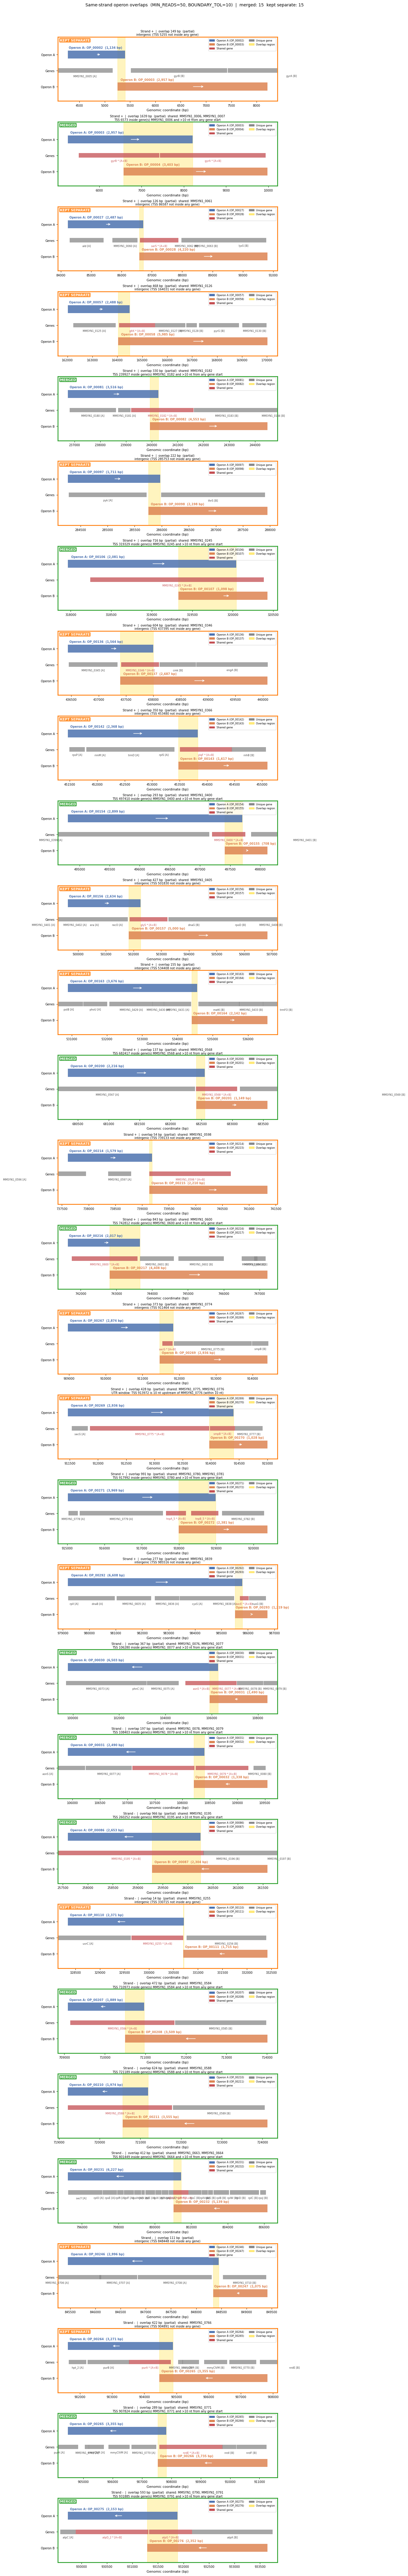

In [30]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_operon_conflict(row, genes_df, merged: bool = False, ax=None):
    """
    Draw a single same-strand operon conflict pair.

    Layout:
      Top track    — Operon A bar
      Middle track — gene bars
      Bottom track — Operon B bar
      Gold shading — overlap region

    merged=True  → frame and title in green  ("MERGED")
    merged=False → frame and title in orange ("KEPT SEPARATE")
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 2.2))

    strand   = row["strand_a"]
    s_a, e_a = int(row["start_a"]), int(row["end_a"])
    s_b, e_b = int(row["start_b"]), int(row["end_b"])
    ovl_s    = max(s_a, s_b)
    ovl_e    = min(e_a, e_b)

    shared   = set(str(row.get("shared_genes","")).split(",")) - {"","nan"}
    loci_a   = set(str(row.get("genes_a","")).split(","))      - {"","nan"}
    loci_b   = set(str(row.get("genes_b","")).split(","))      - {"","nan"}
    all_loci = loci_a | loci_b

    region_genes = genes_df[genes_df["locus_tag"].isin(all_loci)].copy()

    view_s = min(s_a, s_b)
    view_e = max(e_a, e_b)
    pad    = max((view_e - view_s) * 0.05, 50)
    view_s -= pad;  view_e += pad

    # Overlap shading
    ax.axvspan(ovl_s, ovl_e, color="gold", alpha=0.25, zorder=0)

    OPERON_Y = {"A": 1.0, "B": 0.0}
    OPERON_H = 0.25
    GENE_H   = 0.14
    COLORS   = {"A": "#4C72B0", "B": "#DD8452"}

    for label, (s, e) in [("A", (s_a, e_a)), ("B", (s_b, e_b))]:
        y = OPERON_Y[label]
        ax.broken_barh([(s, e - s)], (y - OPERON_H/2, OPERON_H),
                       facecolors=COLORS[label], alpha=0.85, zorder=2)
        mid = (s + e) / 2
        dx  = (e - s) * 0.08 * (1 if strand == "+" else -1)
        ax.annotate("", xy=(mid + dx, y), xytext=(mid, y),
                    arrowprops=dict(arrowstyle="->", color="white", lw=1.2), zorder=3)
        ax.text(s + (e - s) * 0.02, y + OPERON_H/2 + 0.04,
                f"Operon {label}: {row[f'operon_{label.lower()}']}  ({e-s:,} bp)",
                fontsize=7, va="bottom", color=COLORS[label], fontweight="bold")

    for _, gene in region_genes.iterrows():
        lt        = gene["locus_tag"]
        gs, ge    = int(gene["start0"]), int(gene["end0"])
        is_shared = lt in shared
        in_a, in_b = lt in loci_a, lt in loci_b
        color = "#C44E52" if is_shared else "#888888"
        ax.broken_barh([(gs, ge - gs)], (0.5 - GENE_H/2, GENE_H),
                       facecolors=color, alpha=0.75, zorder=2)
        gname = gene["gene_name"]
        claim = "A+B" if (in_a and in_b) else ("A" if in_a else "B")
        parts = [gname if gname else lt]
        if is_shared: parts.append("*")
        parts.append(f"[{claim}]")
        ax.text((gs + ge) / 2, 0.5 - GENE_H/2 - 0.06, " ".join(parts),
                fontsize=6, ha="center", va="top",
                color="#C44E52" if is_shared else "#444444")

    ax.set_xlim(view_s, view_e)
    ax.set_ylim(-0.45, 1.55)
    ax.set_xlabel("Genomic coordinate (bp)", fontsize=8)
    ax.set_yticks([0.0, 0.5, 1.0])
    ax.set_yticklabels(["Operon B", "Genes", "Operon A"], fontsize=7)
    ax.tick_params(axis="x", labelsize=7)

    # ── Merge / separate annotation ──────────────────────────────────────────
    decision_color = "#2ca02c" if merged else "#ff7f0e"   # green / orange
    decision_label = "MERGED" if merged else "KEPT SEPARATE"
    reason         = row.get("reason", "")

    shared_str = f"  shared: {', '.join(sorted(shared))}" if shared else ""
    ax.set_title(
        f"Strand {strand}  |  overlap {int(row['overlap_bp'])} bp  "
        f"({row['relationship']}){shared_str}\n"
        f"{reason}",
        fontsize=7, pad=3
    )

    # Coloured border to instantly signal decision
    for spine in ax.spines.values():
        spine.set_edgecolor(decision_color)
        spine.set_linewidth(2.0)

    # Decision badge (top-left corner)
    ax.text(0.01, 0.97, decision_label,
            transform=ax.transAxes, fontsize=8, fontweight="bold",
            color="white", va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.2", facecolor=decision_color,
                      edgecolor="none", alpha=0.85))

    patches = [
        mpatches.Patch(color=COLORS["A"], label=f"Operon A ({row['operon_a']})"),
        mpatches.Patch(color=COLORS["B"], label=f"Operon B ({row['operon_b']})"),
        mpatches.Patch(color="#C44E52",   label="Shared gene"),
        mpatches.Patch(color="#888888",   label="Unique gene"),
        mpatches.Patch(color="gold",      alpha=0.5, label="Overlap region"),
    ]
    ax.legend(handles=patches, fontsize=6, loc="upper right",
              framealpha=0.7, ncol=2)
    return ax


# ── Plot all same-strand overlap pairs, annotated with merge decision ────────
if len(same_strand_overlaps) == 0:
    print("No same-strand overlaps to plot.")
else:
    # Join merge decision onto same_strand_overlaps via operon_a + operon_b key
    plot_df = same_strand_overlaps.merge(
        decisions_df[["operon_a","operon_b","merge","reason","downstream_tss",
                      "downstream_op","upstream_op"]],
        on=["operon_a","operon_b"], how="left"
    )
    plot_df["merge"] = plot_df["merge"].fillna(False)

    n   = len(plot_df)
    fig, axes = plt.subplots(n, 1, figsize=(12, 2.8 * n), constrained_layout=True)
    if n == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, plot_df.iterrows()):
        plot_operon_conflict(row, genes_df, merged=bool(row["merge"]), ax=ax)

    n_merged   = int(plot_df["merge"].sum())
    n_separate = n - n_merged
    fig.suptitle(
        f"Same-strand operon overlaps  "
        f"(MIN_READS={MIN_READS}, BOUNDARY_TOL={BOUNDARY_TOL})  |  "
        f"merged: {n_merged}  kept separate: {n_separate}",
        fontsize=10, y=1.01
    )

    OUT_FIG = OUT_FOLDER + "/same_strand_conflicts.pdf"
    fig.savefig(OUT_FIG, dpi=300, bbox_inches="tight")
    print(f"Saved: {OUT_FIG}")
    plt.show()


## Step 5b — Merge operons sharing the same sense gene

A separate failure mode occurs when RNase activity is so extensive that no isoform spans the full gene — the surviving isoform clusters land on either side of the cleavage site, each claiming the same gene. These appear as two same-strand operons with identical `sense_gene_loci`. Their coordinate union recovers the true operon span.

In [31]:
# ── Find same-strand operon pairs with identical non-empty sense_gene_loci ──
from collections import defaultdict as _dd

def merge_duplicate_sense_loci(operons: pd.DataFrame) -> pd.DataFrame:
    """
    Merge same-strand operons that share identical sense_gene_loci into one
    operon labelled segmentation_type="isoform_gene_combined".
    Uses Union-Find so transitive chains (A=B, B=C → merge all three) are handled.
    """
    ops = operons.copy().reset_index(drop=True)
    n   = len(ops)

    parent = list(range(n))
    def _find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]; x = parent[x]
        return x
    def _union(x, y):
        parent[_find(x)] = _find(y)

    # Index by (strand, sense_gene_loci) — only non-empty loci
    loci_index = _dd(list)   # (strand, loci_str) → [row indices]
    for i, row in ops.iterrows():
        loci = str(row.get("sense_gene_loci", "") or "").strip()
        if loci:
            loci_index[(row["strand"], loci)].append(i)

    n_groups_merged = 0
    for (strand, loci), indices in loci_index.items():
        if len(indices) > 1:
            for idx in indices[1:]:
                _union(indices[0], idx)
            n_groups_merged += 1

    if n_groups_merged == 0:
        print("No duplicate sense_gene_loci found — nothing to merge.")
        return ops

    clusters = _dd(list)
    for i in range(n):
        clusters[_find(i)].append(i)

    merged_rows = []
    for root, members in clusters.items():
        if len(members) == 1:
            merged_rows.append(ops.iloc[members[0]].to_dict())
        else:
            group  = ops.iloc[members]
            s0     = int(group["start0"].min())
            e0     = int(group["end0"].max())
            strand = group.iloc[0]["strand"]
            base   = group.iloc[0].to_dict()
            base.update({
                "start0":               s0,
                "end0":                 e0,
                "length":               e0 - s0,
                "tss":                  s0 if strand == "+" else e0,
                "tts":                  e0 if strand == "+" else s0,
                "n_isoforms":           int(group["n_isoforms"].sum()),
                "n_reads_total":        int(group["n_reads_total"].sum()),
                "sense_gene_count":     int(group["sense_gene_count"].max()),
                "sense_gene_loci":      group.iloc[0]["sense_gene_loci"],
                "sense_gene_names":     group.iloc[0]["sense_gene_names"],
                "antisense_gene_count": int(group["antisense_gene_count"].max()),
                "antisense_gene_loci":  ",".join(filter(None,
                    group["antisense_gene_loci"].fillna("").tolist())),
                "antisense_gene_names": ",".join(filter(None,
                    group["antisense_gene_names"].fillna("").tolist())),
                "member_ids":           ",".join(filter(None,
                    group["member_ids"].fillna("").tolist())),
                "segmentation_type":    "isoform_gene_combined",
            })
            print(f"  Merged {len(members)} operons for gene(s) "
                  f"'{group.iloc[0]['sense_gene_loci']}' "
                  f"(strand {strand}, {s0}–{e0})")
            merged_rows.append(base)

    result = (pd.DataFrame(merged_rows)
              .sort_values(["chrom", "start0"])
              .reset_index(drop=True))
    if "operon_id" in result.columns:
        result = result.drop(columns=["operon_id"])
    result.insert(0, "operon_id",
        [f"OP_{i+1:05d}" for i in range(len(result))])
    return result


print("Merging operons with duplicate sense_gene_loci...")
operons_merged = merge_duplicate_sense_loci(operons_merged)

for stype in ["isoform_operon", "isoform_operon_merged", "isoform_gene_combined"]:
    n = (operons_merged["segmentation_type"] == stype).sum()
    print(f"  {stype:<30} {n}")


Merging operons with duplicate sense_gene_loci...
  Merged 2 operons for gene(s) 'MMSYN1_0034' (strand +, 54194–59688)
  Merged 2 operons for gene(s) 'MMSYN1_0550' (strand +, 657129–659734)
  isoform_operon                 0
  isoform_operon_merged          14
  isoform_gene_combined          2


In [32]:
# ── 2. Cross-strand overlap (antisense pairs) ───────────────────────────────
# Use operons_merged so cross-strand analysis reflects the post-merge state
plus_ops  = operons_merged[operons_merged["strand"] == "+"].copy()
minus_ops = operons_merged[operons_merged["strand"] == "-"].copy()
cross_strand = find_overlapping_pairs(plus_ops, minus_ops, same_strand=False)

print(f"\nCross-strand (antisense) overlapping operon pairs: {len(cross_strand)}")
if len(cross_strand) > 0:
    print(f"\nOverlap length distribution (bp):")
    print(cross_strand["overlap_bp"].describe().astype(int).to_string())
    print(f"\nRelationship breakdown:")
    print(cross_strand["relationship"].value_counts().to_string())
    print()
    display(cross_strand.sort_values("overlap_bp", ascending=False).head(20))


Cross-strand (antisense) overlapping operon pairs: 37

Overlap length distribution (bp):
count      37
mean      453
std       599
min         6
25%        33
50%       123
75%       713
max      2307

Relationship breakdown:
relationship
partial         32
b_contains_a     3
a_contains_b     2



,operon_a,strand_a,start_a,end_a,operon_b,strand_b,start_b,end_b,overlap_bp,frac_of_a,frac_of_b,relationship
32,OP_00252,+,908963,911837,OP_00251,-,904469,911270,2307,0.803,0.339,partial
21,OP_00184,+,645753,647412,OP_00183,-,642236,647920,1659,1.000,0.292,b_contains_a
34,OP_00254,+,911464,914400,OP_00253,-,911392,913102,1638,0.558,0.958,partial
15,OP_00114,+,372078,373636,OP_00113,-,371740,374305,1558,1.000,0.607,b_contains_a
36,OP_00263,+,939073,941437,OP_00264,-,940064,941608,1373,0.581,0.889,partial
17,OP_00132,+,442994,444839,OP_00133,-,443438,444523,1085,0.588,1.000,a_contains_b
8,OP_00051,+,159370,161939,OP_00052,-,159935,160903,968,0.377,1.000,a_contains_b
25,OP_00222,+,812168,813093,OP_00221,-,812149,813731,925,1.000,0.585,b_contains_a
16,OP_00118,+,389566,391154,OP_00117,-,388236,390364,798,0.503,0.375,partial
20,OP_00166,+,578872,581990,OP_00167,-,581277,584249,713,0.229,0.240,partial


## Step 6 — Gene coverage

For each of the 911 annotated Syn1 genes, determine whether it is transcriptionally covered by the isoform-derived operons. Four coverage categories:

| Category | Meaning |
|---|---|
| `both` | Covered by operons on both strands (sense + antisense) |
| `sense_only` | Covered only by a same-strand operon — normal transcription |
| `antisense_only` | Only an antisense operon overlaps — the gene itself may be silent or very lowly expressed |
| `uncovered` | No operon on either strand — candidate for Step 7 rescue |

Genes in the `uncovered` category are most likely lowly expressed (below `MIN_READS = 50`) rather than truly silent, since Syn1 is a minimal cell containing only essential genes.

In [33]:
# ── Gene coverage: derived by inverting operons_annotated ──────────────────
def find_gene_coverage(genes: pd.DataFrame,
                       operons: pd.DataFrame) -> pd.DataFrame:
    """
    Invert sense/antisense loci columns in `operons` to map each gene back to
    its covering operons.  O(n_operons) — no per-gene operon scan needed.
    Returns genes_df augmented with:
      sense_operon_count / sense_covering_ops
      antisense_operon_count / antisense_covering_ops
      coverage_type: "both" | "sense_only" | "antisense_only" | "uncovered"
    """
    sense_map     = defaultdict(list)
    antisense_map = defaultdict(list)
    for _, op in operons.iterrows():
        oid = op["operon_id"]
        for locus in str(op.get("sense_gene_loci", "") or "").split(","):
            if locus:
                sense_map[locus].append(oid)
        for locus in str(op.get("antisense_gene_loci", "") or "").split(","):
            if locus:
                antisense_map[locus].append(oid)

    gdf = genes.copy()
    s_counts, s_ops, a_counts, a_ops, cov_types = [], [], [], [], []
    for _, gene in gdf.iterrows():
        lt = gene["locus_tag"]
        s  = sense_map.get(lt, [])
        a  = antisense_map.get(lt, [])
        s_counts.append(len(s));  s_ops.append(",".join(s))
        a_counts.append(len(a));  a_ops.append(",".join(a))
        if s and a:    cov_types.append("both")
        elif s:        cov_types.append("sense_only")
        elif a:        cov_types.append("antisense_only")
        else:          cov_types.append("uncovered")

    gdf["sense_operon_count"]     = s_counts
    gdf["sense_covering_ops"]     = s_ops
    gdf["antisense_operon_count"] = a_counts
    gdf["antisense_covering_ops"] = a_ops
    gdf["coverage_type"]          = cov_types
    return gdf

genes_covered = find_gene_coverage(genes_df, operons_merged)

n_both      = (genes_covered["coverage_type"] == "both").sum()
n_sense     = (genes_covered["coverage_type"] == "sense_only").sum()
n_anti_only = (genes_covered["coverage_type"] == "antisense_only").sum()
n_uncov     = (genes_covered["coverage_type"] == "uncovered").sum()
total       = len(genes_df)

print(f"Gene coverage summary (out of {total} genes):")
print(f"  Both sense + antisense:              {n_both:>4}  ({n_both/total*100:.1f}%)")
print(f"  Sense only:                          {n_sense:>4}  ({n_sense/total*100:.1f}%)")
print(f"  Antisense only:                      {n_anti_only:>4}  ({n_anti_only/total*100:.1f}%)")
print(f"  Uncovered (no operon either strand): {n_uncov:>4}  ({n_uncov/total*100:.1f}%)")

if n_anti_only > 0:
    print(f"\nGenes covered by antisense operon only:")
    display(genes_covered[genes_covered["coverage_type"] == "antisense_only"]
            [["locus_tag","gene_name","product","strand","start0","end0",
              "antisense_covering_ops"]].reset_index(drop=True))

uncovered_genes = genes_covered[genes_covered["coverage_type"] == "uncovered"].copy()
uncovered_genes["gene_length"] = uncovered_genes["end0"] - uncovered_genes["start0"]
print(f"\nUncovered genes by strand:")
print(uncovered_genes["strand"].value_counts().to_string())
print(f"\nUncovered gene length distribution (bp):")
print(uncovered_genes["gene_length"].describe().astype(int).to_string())
print(f"\nUncovered genes (first 30):")
display(uncovered_genes[["locus_tag","gene_name","product","chrom","strand",
                          "start0","end0","gene_length"]]
        .head(30).reset_index(drop=True))


Gene coverage summary (out of 911 genes):
  Both sense + antisense:                48  (5.3%)
  Sense only:                           638  (70.0%)
  Antisense only:                        25  (2.7%)
  Uncovered (no operon either strand):  200  (22.0%)

Genes covered by antisense operon only:


,locus_tag,gene_name,product,strand,start0,end0,antisense_covering_ops
0,MMSYN1_0918,his3,imidazoleglycerol-phosphate dehydratase,-,27638,28301,OP_00009
1,MMSYN1_0057,,conserved hypothetical protein,+,83286,83577,OP_00024
2,MMSYN1_0058,,conserved hypothetical protein,+,83595,84177,OP_00024
3,MMSYN1_0116,,conserved hypothetical protein,-,151367,151808,OP_00048
4,MMSYN1_0135,,hypothetical protein,-,176448,176562,OP_00057
5,MMSYN1_0174,,conserved hypothetical protein,+,228149,228296,OP_00073
6,MMSYN1_0204,sun,ribosomal RNA small subunit methyltransferase B,+,266176,267436,OP_00084
7,MMSYN1_0209,murQ,N-acetylmuramic acid 6-phosphate etherase,-,272098,273016,"OP_00085,OP_00086"
8,MMSYN1_0210,,PTS system N-acetylmuramic acid-specific eiibc...,-,273008,274706,OP_00086
9,MMSYN1_0251,,conserved hypothetical protein,+,325822,326515,OP_00102



Uncovered genes by strand:
strand
+    107
-     93

Uncovered gene length distribution (bp):
count     200
mean      996
std       751
min        75
25%       505
50%       799
75%      1242
max      5322

Uncovered genes (first 30):


,locus_tag,gene_name,product,chrom,strand,start0,end0,gene_length
0,MMSYN1_0003,rnmV,ribonuclease M5,CP002027.1,+,2674,3217,543
1,MMSYN1_0004,ksgA,dimethyladenosine transferase,CP002027.1,+,3206,4007,801
2,MMSYN1_0008,,ribose/Galactose ABC transporter_ permease com...,CP002027.1,-,9990,10968,978
3,MMSYN1_0916,,RNAI,CP002027.1,+,25110,25215,105
4,MMSYN1_0022,,sorbitol-6-phosphate 2-dehydrogenase (Glucitol...,CP002027.1,-,38920,39679,759
5,MMSYN1_0024,,PSEUDOGENE - divergent AAA domain family,CP002027.1,-,41508,42891,1383
6,MMSYN1_0033,,hypothetical protein,CP002027.1,-,50957,54116,3159
7,MMSYN1_0035,,conserved hypothetical protein,CP002027.1,+,59774,60968,1194
8,MMSYN1_0048,,cytosine deaminase,CP002027.1,-,74944,75412,468
9,MMSYN1_0049,srpB,Bacterial signal recognition particle RNA,CP002027.1,-,75392,75491,99


## Step 7 — Rescue uncovered genes

Genes not covered by any isoform operon (Step 6 `uncovered`) are recovered through three complementary strategies:

**7a — BAM spanning read count:** Count PacBio FLNC reads that fully span each uncovered gene's coordinates in the raw BAM file. A read must map from ≤ gene start to ≥ gene end — this is stricter than counting any overlapping read and avoids contamination from adjacent high-expression operons. Even 1–2 spanning reads confirms basal transcription activity.

**7b — Consecutive gene rescue:** When multiple consecutive uncovered genes on the same strand are separated by gaps ≤ 500 bp, they likely form a single lowly-expressed operon. Any isoform (no read-depth filter) that spans the entire gene group is used as evidence; the best-supported spanning isoform defines the operon boundaries.

**7c — rRNA operons (hard-coded):** The two rRNA operons (5S–23S–16S on the minus strand, at ~92–97 kb and ~637–642 kb) are not captured by isoform clustering because rRNA is enormously abundant and heavily processed into mature subunits rather than read as full-length polycistronic transcripts. These operons are annotated directly from GFF3 coordinates.

All rescued operons are passed through `annotate_operons_with_genes` to populate `sense_gene_loci` / `antisense_gene_loci`, ensuring they are correctly counted in the final gene coverage summary.

In [34]:
import pysam

BAM_FILE = MOTHER_FOLDER + "/syn1.PacBio.FLNC.sorted.HQ.bam"

# ══════════════════════════════════════════════════════════════════════════════
# 4a — Count reads that span the ENTIRE gene region (reference_start ≤ gene_start
#      AND reference_end ≥ gene_end).  A simple bam.count() would include any
#      read that merely overlaps the region by even 1 bp — reads from adjacent
#      high-expression operons would inflate the count for low-expression neighbors.
#      Full-span counting is stricter and biologically more meaningful: it asks
#      "is there a transcript that covers this whole gene?"
# ══════════════════════════════════════════════════════════════════════════════
def count_spanning_reads(bam_path: str, chrom: str,
                         start0: int, end0: int) -> int:
    """Count reads whose mapped span fully covers [start0, end0)."""
    n = 0
    with pysam.AlignmentFile(bam_path, "rb") as bam:
        for read in bam.fetch(chrom, start0, end0):
            if (not read.is_unmapped and
                    read.reference_start <= start0 and
                    read.reference_end   >= end0):
                n += 1
    return n

spanning_counts = []
for _, gene in uncovered_genes.iterrows():
    spanning_counts.append(
        count_spanning_reads(BAM_FILE, gene["chrom"],
                             gene["start0"], gene["end0"])
    )

uncovered_genes = uncovered_genes.copy()
uncovered_genes["spanning_read_count"] = spanning_counts

print("Spanning-read distribution for uncovered genes:")
bins   = [0, 1, 5, 10, 20, 50, 100, 99999]
labels = ["0", "1-4", "5-9", "10-19", "20-49", "50-99", "≥100"]
for lo, hi, lbl in zip(bins, bins[1:], labels):
    n = ((uncovered_genes["spanning_read_count"] >= lo) &
         (uncovered_genes["spanning_read_count"] < hi)).sum()
    print(f"  {lbl:>6} reads: {n} genes")


Spanning-read distribution for uncovered genes:
       0 reads: 10 genes
     1-4 reads: 23 genes
     5-9 reads: 22 genes
   10-19 reads: 24 genes
   20-49 reads: 27 genes
   50-99 reads: 30 genes
    ≥100 reads: 64 genes


In [ ]:
uncovered_genes.sort_values("spanning_read_count", ascending=False).head(20)

,chrom,strand,start0,end0,locus_tag,gene_name,product,sense_operon_count,sense_covering_ops,antisense_operon_count,antisense_covering_ops,coverage_type,gene_length,spanning_read_count
53,CP002027.1,-,74944,75412,MMSYN1_0048,,cytosine deaminase,0,,0,,uncovered,468,923
590,CP002027.1,-,726552,727071,MMSYN1_0590,,type III restriction enzyme_ res subunit,0,,0,,uncovered,519,864
589,CP002027.1,+,726176,726560,MMSYN1_0927,,hypothetical protein,0,,0,,uncovered,384,857
625,CP002027.1,-,766798,767731,MMSYN1_0625,arcC_1,carbamate kinase 1,0,,0,,uncovered,933,832
284,CP002027.1,+,362525,363143,MMSYN1_0283,rnhA,ribonuclease HI,0,,0,,uncovered,618,811
111,CP002027.1,-,141631,142030,MMSYN1_0107,nusB,transcription antitermination factor NusB,0,,0,,uncovered,399,744
815,CP002027.1,+,959416,959686,MMSYN1_0929,,conserved domain protein,0,,0,,uncovered,270,739
575,CP002027.1,-,700692,701136,MMSYN1_0578,,conserved hypothetical protein,0,,0,,uncovered,444,644
386,CP002027.1,+,471936,472617,MMSYN1_0385,,PSEUDOGENE - putative liporotein,0,,0,,uncovered,681,592
170,CP002027.1,+,214264,215275,MMSYN1_0166,,oligopeptide ABC transporter_ permease compone...,0,,0,,uncovered,1011,578


In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# 4b — Consecutive-gene rescue: check for spanning isoforms (any depth)
# ══════════════════════════════════════════════════════════════════════════════
# Sort uncovered genes by chrom, strand, start
ug = uncovered_genes.sort_values(["chrom", "strand", "start0"]).reset_index(drop=True)

# Group consecutive genes on same strand (gap ≤ MAX_GENE_GAP bp)
MAX_GENE_GAP = 500   # bp between adjacent gene ends — tune if needed

def group_consecutive(df):
    """Return list of gene-index groups that are consecutive on same strand."""
    groups = []
    current = [0]
    for i in range(1, len(df)):
        prev, cur = df.iloc[i - 1], df.iloc[i]
        if (cur["strand"] == prev["strand"] and
                cur["chrom"] == prev["chrom"] and
                cur["start0"] - prev["end0"] <= MAX_GENE_GAP):
            current.append(i)
        else:
            groups.append(current)
            current = [i]
    groups.append(current)
    return groups

cons_groups = group_consecutive(ug)
multi_groups = [g for g in cons_groups if len(g) > 1]
print(f"\nConsecutive uncovered gene groups (gap ≤ {MAX_GENE_GAP} bp): {len(multi_groups)}")

# For each multi-gene group, check if any isoform spans the full region
# (using ALL isoforms from df, regardless of read depth)
df_all_strand = {s: df[df["strand"] == s].reset_index(drop=True)
                 for s in ["+", "-"]}

spanning_rescues = []
for grp in multi_groups:
    genes_in_grp = ug.iloc[grp]
    strand  = genes_in_grp.iloc[0]["strand"]
    chrom   = genes_in_grp.iloc[0]["chrom"]
    reg_s   = genes_in_grp["start0"].min()
    reg_e   = genes_in_grp["end0"].max()
    loci    = ",".join(genes_in_grp["locus_tag"].tolist())

    iso_s = df_all_strand[strand]
    # isoform must span: start <= reg_s+BOUNDARY_TOL AND end >= reg_e-BOUNDARY_TOL
    spanning = iso_s[
        (iso_s["start0"] <= reg_s + BOUNDARY_TOL) &
        (iso_s["end0"]   >= reg_e - BOUNDARY_TOL)
    ]
    if len(spanning) > 0:
        best = spanning.loc[spanning["n_reads"].idxmax()]
        spanning_rescues.append({
            "chrom":      chrom,
            "strand":     strand,
            "start0":     int(reg_s),
            "end0":       int(reg_e),
            "n_genes":    len(grp),
            "gene_loci":  loci,
            "best_isoform": best["isoform_id"],
            "n_reads":    int(best["n_reads"]),
            "segmentation_type": "rescue_multiple",
        })

span_df = pd.DataFrame(spanning_rescues) if spanning_rescues else pd.DataFrame()
print(f"Consecutive groups rescued by spanning isoform: {len(span_df)}")
if len(span_df):
    display(span_df)



Consecutive uncovered gene groups (gap ≤ 500 bp): 44
Consecutive groups rescued by spanning isoform: 13


,chrom,strand,start0,end0,n_genes,gene_loci,best_isoform,n_reads,segmentation_type
0,CP002027.1,+,2674,4007,2,"MMSYN1_0003,MMSYN1_0004",ISO_000157,2,rescue_multiple
1,CP002027.1,+,213004,215275,2,"MMSYN1_0165,MMSYN1_0166",ISO_008349,11,rescue_multiple
2,CP002027.1,+,344440,345422,2,"MMSYN1_0270,MMSYN1_0271",ISO_016805,2,rescue_multiple
3,CP002027.1,+,537768,539344,2,"MMSYN1_0435,MMSYN1_0436",ISO_026121,3,rescue_multiple
4,CP002027.1,+,887084,888137,2,"MMSYN1_0752,MMSYN1_0753",ISO_031632,3,rescue_multiple
5,CP002027.1,+,996009,998095,2,"MMSYN1_0843,MMSYN1_0844",ISO_034883,2,rescue_multiple
6,CP002027.1,-,126219,127690,2,"MMSYN1_0093,MMSYN1_0094",ISO_040484,3,rescue_multiple
7,CP002027.1,-,201663,203734,2,"MMSYN1_0156,MMSYN1_0157",ISO_041384,12,rescue_multiple
8,CP002027.1,-,274827,275868,2,"MMSYN1_0211,MMSYN1_0212",ISO_043369,5,rescue_multiple
9,CP002027.1,-,334374,335903,2,"MMSYN1_0258,MMSYN1_0259",ISO_045218,8,rescue_multiple


In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# 4c — Build rescue operons
# ══════════════════════════════════════════════════════════════════════════════
rescued_loci = set()
if len(span_df):
    for loci_str in span_df["gene_loci"]:
        rescued_loci.update(loci_str.split(","))

# rRNA genes are handled separately in 4d — exclude them here
rrna_loci = {"MMSYN1_0067","MMSYN1_0068","MMSYN1_0069",
             "MMSYN1_0532","MMSYN1_0533","MMSYN1_0534"}
rescued_loci.update(rrna_loci)

remaining_ug = ug[~ug["locus_tag"].isin(rescued_loci)].copy()

single_gene_ops = []
for _, gene in remaining_ug.iterrows():
    single_gene_ops.append({
        "chrom":         gene["chrom"],
        "strand":        gene["strand"],
        "start0":        int(gene["start0"]),
        "end0":          int(gene["end0"]),
        "n_isoforms":    0,
        "n_reads_total": int(gene["spanning_read_count"]),
        "member_ids":    "",
        "gene_count":    1,
        "gene_loci":     gene["locus_tag"],
        "gene_names":    gene["gene_name"],
        "length":        int(gene["end0"] - gene["start0"]),
        "segmentation_type":   "rescue_single",
    })

print(f"Single-gene BAM-rescue operons: {len(single_gene_ops)}")
print(f"  (of which 0 spanning reads:  "
      f"{sum(1 for g in single_gene_ops if g['n_reads_total'] == 0)})")


Single-gene BAM-rescue operons: 166
  (of which 0 spanning reads:  8)


In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# 4d — rRNA operons (hard-coded)
# Both rRNA clusters are on the minus strand.
# Transcription goes 16S → 23S → 5S (high→low coordinate).
# So TSS = end0 (high coord), TTS = start0 (low coord).
# ══════════════════════════════════════════════════════════════════════════════
RRNA_OPERONS = [
    {   # cluster 1: MMSYN1_0067(5S)–0068(23S)–0069(16S), minus strand
        # GFF coords (1-based): rrf 92148-92256, rrl 92331-95225, rrs 95457-96980
        # 0-based: genomic min = 92147, genomic max = 96980
        "chrom": "CP002027.1", "strand": "-",
        "start0": 92147,   # genomic min (0-based) = TTS for minus strand
        "end0":   96980,   # genomic max           = TSS for minus strand
        "n_isoforms": 0, "n_reads_total": 0, "member_ids": "",
        "gene_count": 3,
        "gene_loci":  "MMSYN1_0067,MMSYN1_0068,MMSYN1_0069",
        "gene_names": "rrf,rrl,rrs",
        "segmentation_type": "rescue_multiple",
    },
    {   # cluster 2: MMSYN1_0532(5S)–0533(23S)–0534(16S), minus strand
        # GFF coords (1-based): rrf 637296-637404, rrl 637479-640373, rrs 640604-642127
        # 0-based: genomic min = 637295, genomic max = 642127
        "chrom": "CP002027.1", "strand": "-",
        "start0": 637295,
        "end0":   642127,
        "n_isoforms": 0, "n_reads_total": 0, "member_ids": "",
        "gene_count": 3,
        "gene_loci":  "MMSYN1_0532,MMSYN1_0533,MMSYN1_0534",
        "gene_names": "rrf,rrl,rrs",
        "segmentation_type": "rescue_multiple",
    },
]

# Count spanning reads across each rRNA operon
for rop in RRNA_OPERONS:
    rop["n_reads_total"] = count_spanning_reads(
        BAM_FILE, rop["chrom"], rop["start0"], rop["end0"])

print("rRNA operons:")
for rop in RRNA_OPERONS:
    print(f"  {rop['gene_loci']}  {rop['strand']}  "
          f"{rop['start0']}–{rop['end0']}  {rop['n_reads_total']} spanning reads")


rRNA operons:
  MMSYN1_0067,MMSYN1_0068,MMSYN1_0069  -  92147–96980  0 spanning reads
  MMSYN1_0532,MMSYN1_0533,MMSYN1_0534  -  637295–642127  0 spanning reads


In [ ]:

# ══════════════════════════════════════════════════════════════════════════════
# 4e — Merge rescued operons + add TSS/TTS directional coordinates
# ══════════════════════════════════════════════════════════════════════════════
rescue_rows = []

if len(span_df):
    for _, r in span_df.iterrows():
        rescue_rows.append({
            "chrom":         r["chrom"],
            "strand":        r["strand"],
            "start0":        int(r["start0"]),
            "end0":          int(r["end0"]),
            "n_isoforms":    1,
            "n_reads_total": int(r["n_reads"]),
            "member_ids":    r["best_isoform"],
            "gene_count":    int(r["n_genes"]),
            "gene_loci":     r["gene_loci"],
            "gene_names":    "",
            "length":        int(r["end0"] - r["start0"]),
            "segmentation_type":   "rescue_multiple",
        })

rescue_rows.extend(single_gene_ops)
rescue_rows.extend(RRNA_OPERONS)

rescue_df = pd.DataFrame(rescue_rows)
rescue_df["length"] = rescue_df["end0"] - rescue_df["start0"]

# ── Populate sense/antisense gene loci for find_gene_coverage ──────────────
# rescue_df rows already have gene_loci set to exactly the intended locus/loci
# (one gene for single_gene_bam, N genes for consecutive_spanning/rRNA).
# We must NOT let annotate_operons_with_genes overwrite gene_loci/gene_count
# because it would pick up any gene that genomically overlaps the coordinates,
# potentially adding unintended neighbours to a single_gene_bam operon.
# Instead, copy gene_loci directly into sense_gene_loci (all rescue operons
# are sense by construction) and compute antisense_gene_loci independently.
opp = {"+": "-", "-": "+"}
s_loci, s_names, s_counts = [], [], []
a_loci, a_names, a_counts = [], [], []
for _, op in rescue_df.iterrows():
    overlaps  = (genes_df["start0"] < op["end0"]) & (genes_df["end0"] > op["start0"])
    antisense = genes_df[overlaps & (genes_df["strand"] == opp[op["strand"]])]
    # sense: use the already-correct gene_loci, not a fresh scan
    s_loci.append(str(op.get("gene_loci", "") or ""))
    s_names.append(str(op.get("gene_names", "") or ""))
    s_counts.append(len([l for l in str(op.get("gene_loci","") or "").split(",") if l]))
    a_loci.append(",".join(antisense["locus_tag"].tolist()))
    a_names.append(",".join(antisense["gene_name"].tolist()))
    a_counts.append(len(antisense))
rescue_df["sense_gene_loci"]      = s_loci
rescue_df["sense_gene_names"]      = s_names
rescue_df["sense_gene_count"]      = s_counts
rescue_df["antisense_gene_loci"]   = a_loci
rescue_df["antisense_gene_names"]  = a_names
rescue_df["antisense_gene_count"]  = a_counts

# Tag segmentation_type on operons_merged:
# rows that went through ss_merge already have "isoform_operon_merged";
# rows that were never in a conflict pair have NaN — fill those now.
operons_merged = operons_merged.copy()
operons_merged["segmentation_type"] = (
    operons_merged.get("segmentation_type", pd.Series(dtype=str))
    .fillna("isoform_operon")
)

# Combine all operons — sort by genomic position (start0 always = min coord)
all_operons = pd.concat(
    [operons_merged, rescue_df], ignore_index=True
).sort_values(["chrom", "start0"]).reset_index(drop=True)

# Drop any pre-existing operon_id before re-assigning
if "operon_id" in all_operons.columns:
    all_operons = all_operons.drop(columns=["operon_id"])
all_operons.insert(0, "operon_id",
    [f"OP_{i+1:05d}" for i in range(len(all_operons))])

# ── Add TSS / TTS directional coordinates ───────────────────────────────────
# For + strand: TSS = start0 (5′ end, low coord), TTS = end0 (3′ end, high coord)
# For − strand: TSS = end0  (5′ end, high coord), TTS = start0 (3′ end, low coord)
all_operons["tss"] = np.where(all_operons["strand"] == "+",
                               all_operons["start0"], all_operons["end0"])
all_operons["tts"] = np.where(all_operons["strand"] == "+",
                               all_operons["end0"],  all_operons["start0"])

print(f"Final operon count: {len(all_operons)}")
for stype in all_operons["segmentation_type"].unique():
    n = (all_operons["segmentation_type"] == stype).sum()
    print(f"  {stype:<30} {n}")
n_nan = all_operons["segmentation_type"].isna().sum()
if n_nan:
    print(f"  WARNING: {n_nan} operons with no segmentation_type (NaN)")

print("\nRescue operons (non-isoform):")
display(all_operons[all_operons["segmentation_type"] != "isoform_operon"]
        [["operon_id","strand","tss","tts","length","gene_loci",
          "n_reads_total","segmentation_type"]].reset_index(drop=True))


Final operon count: 480
  isoform_operon                 283
  rescue_multiple                15
  isoform_operon_merged          14
  rescue_single                  166
  isoform_gene_combined          2

Rescue operons (non-isoform):


,operon_id,strand,tss,tts,length,gene_loci,n_reads_total,segmentation_type
0,OP_00002,+,2674,4007,1333,"MMSYN1_0003,MMSYN1_0004",2,rescue_multiple
1,OP_00004,+,5255,9976,4721,"MMSYN1_0006,MMSYN1_0007",1003,isoform_operon_merged
2,OP_00005,-,10968,9990,978,MMSYN1_0008,332,rescue_single
3,OP_00010,+,25110,25215,105,MMSYN1_0916,205,rescue_single
4,OP_00015,-,39679,38920,759,MMSYN1_0022,154,rescue_single
...,...,...,...,...,...,...,...,...
192,OP_00473,+,1070054,1070690,636,MMSYN1_0900,50,rescue_single
193,OP_00474,+,1070922,1071534,612,MMSYN1_0901,3,rescue_single
194,OP_00475,+,1071823,1072303,480,MMSYN1_0902,81,rescue_single
195,OP_00476,+,1072803,1073379,576,MMSYN1_0903,11,rescue_single


## Step 8 — Save outputs

Write the final operon table and gene coverage files. The operon table (`operons.candidate_blocks.tsv`) includes all segmentation types:

| `segmentation_type` | Origin |
|---|---|
| `isoform_operon` | Directly from containment clustering (Step 2) |
| `isoform_operon_merged` | Two overlapping isoform operons merged by TSS rule (Step 5a) |
| `isoform_gene_combined` | Two isoform operons sharing a gene merged by duplicate-loci rule (Step 5b) |
| `rescue_multiple` | Consecutive low-expression genes or rRNA operon (Step 7b/7c) |
| `rescue_single` | Single lowly-expressed gene from BAM evidence (Step 7a) |

BED6 files (plus and minus strand separately) are written for direct loading into IGV.

In [ ]:
# ── Final gene coverage check ───────────────────────────────────────────────
genes_covered_final = find_gene_coverage(genes_df, all_operons)

n_both      = (genes_covered_final["coverage_type"] == "both").sum()
n_sense     = (genes_covered_final["coverage_type"] == "sense_only").sum()
n_anti_only = (genes_covered_final["coverage_type"] == "antisense_only").sum()
n_uncov     = (genes_covered_final["coverage_type"] == "uncovered").sum()
total       = len(genes_df)

print(f"Final gene coverage ({total} genes):")
print(f"  Both sense + antisense:              {n_both:>4}  ({n_both/total*100:.1f}%)")
print(f"  Sense only:                          {n_sense:>4}  ({n_sense/total*100:.1f}%)")
print(f"  Antisense only:                      {n_anti_only:>4}  ({n_anti_only/total*100:.1f}%)")
print(f"  Uncovered (no operon either strand): {n_uncov:>4}  ({n_uncov/total*100:.1f}%)")

if n_uncov > 0:
    display(genes_covered_final[genes_covered_final["coverage_type"] == "uncovered"]
            [["locus_tag","gene_name","product","strand","start0","end0"]]
            .reset_index(drop=True))

# ── Save all outputs ─────────────────────────────────────────────────────────
OUT_TSV = OUT_FOLDER + "/operons.candidate_blocks.tsv"
all_operons.to_csv(OUT_TSV, sep="\t", index=False)
print(f"\nSaved: {OUT_TSV}  ({len(all_operons)} operons)")
print(f"Columns: {list(all_operons.columns)}")

OUT_GCOV = OUT_FOLDER + "/gene_operon_coverage.tsv"
genes_covered_final.to_csv(OUT_GCOV, sep="\t", index=False)
print(f"Saved: {OUT_GCOV}")

OUT_UNCOV = OUT_FOLDER + "/uncovered_genes.tsv"
still_uncov = genes_covered_final[genes_covered_final["coverage_type"] == "uncovered"]
still_uncov.to_csv(OUT_UNCOV, sep="\t", index=False)
print(f"Saved: {OUT_UNCOV}  ({len(still_uncov)} genes)")

# ── BED6 for IGV ─────────────────────────────────────────────────────────────
def to_bed6(df, score_col="n_reads_total", name_col="operon_id"):
    bed = df[["chrom", "start0", "end0", name_col, score_col, "strand"]].copy()
    bed.columns = ["chrom", "chromStart", "chromEnd", "name", "score", "strand"]
    bed["score"] = bed["score"].clip(upper=1000).astype(int)
    return bed

to_bed6(all_operons[all_operons["strand"] == "+"]).to_csv(
    OUT_FOLDER + "/operons.candidate_blocks.plus.bed",  sep="\t", index=False, header=False)
to_bed6(all_operons[all_operons["strand"] == "-"]).to_csv(
    OUT_FOLDER + "/operons.candidate_blocks.minus.bed", sep="\t", index=False, header=False)
print("BED files written for IGV inspection.")


Final gene coverage (911 genes):
  Both sense + antisense:                53  (5.8%)
  Sense only:                           833  (91.4%)
  Antisense only:                        25  (2.7%)
  Uncovered (no operon either strand):    0  (0.0%)

Saved: ../Operon_Annotation_Visualization/operons.candidate_blocks.tsv  (480 operons)
Columns: ['operon_id', 'chrom', 'strand', 'start0', 'end0', 'n_isoforms', 'n_reads_total', 'member_ids', 'length', 'tss', 'tts', 'sense_gene_count', 'sense_gene_loci', 'sense_gene_names', 'antisense_gene_count', 'antisense_gene_loci', 'antisense_gene_names', 'gene_count', 'gene_loci', 'gene_names', 'segmentation_type']
Saved: ../Operon_Annotation_Visualization/gene_operon_coverage.tsv
Saved: ../Operon_Annotation_Visualization/uncovered_genes.tsv  (0 genes)
BED files written for IGV inspection.
